## Ginni Impurity

**Gini Impurity** (often misspelled as *Ginni*) is a metric used in Decision Tree algorithms to measure the "impurity" or mixture of classes in a dataset. 

It calculates the probability of a randomly chosen element from the set being incorrectly labeled if it were randomly labeled according to the distribution of labels in the subset.

### Key Concepts
* **Formula:** $Gini = 1 - \sum_{i=1}^{C} (p_i)^2$
  * Where $p_i$ is the probability (proportion) of an item belonging to class $i$, and $C$ is the total number of classes.
* **Range:** For a binary classification, Gini Impurity ranges from:
  * **$0$ (Pure node):** All elements belong to a single class (perfectly classified).
  * **$0.5$ (Max impurity):** Elements are split equally ($50/50$) between two classes.

---

### Python Code Example

#### 1. Manual Calculation in Python
Here is how you calculate Gini Impurity for a set of items:


In [1]:
from sklearn.tree import DecisionTreeClassifier

# Features: [Weight (grams)]
X = [[120], [130], [80], [70]]
# Labels: 1 = Apple, 0 = Orange
y = [1, 1, 0, 0]

# Train the model (uses Gini impurity by default)
model = DecisionTreeClassifier()
model.fit(X, y)

# Predict the class for a fruit weighing 110 grams
print("Prediction for 110g:", model.predict([[110]])) # Output: [1] (Apple)


Prediction for 110g: [1]


### 1. Memorization (Overfitting)
* **What it is:** The model learns the training data *too* perfectly—including its noise, outliers, and random details—instead of the general trend.
* **Real-World Analogy:** A student who memorizes the exact questions and answers from a practice exam word-for-word. If a question on the actual exam is even slightly different, they cannot answer it.
* **Key Indicators:**
  * Training Accuracy: Very High (e.g., 99%-100%)
  * Testing/New Data Accuracy: Low (e.g., 65%)

---

### 2. Generalization (The Goal)
* **What it is:** The model's ability to apply what it learned during training to make correct predictions on completely new, unseen data.
* **Real-World Analogy:** A student who studies the core concepts and logic. Even if the actual exam has brand-new questions, they can solve them easily.
* **Key Indicators:**
  * Training Accuracy: High (e.g., 90%)
  * Testing/New Data Accuracy: High (e.g., 89%)

---

### 3. Underfitting
* **What it is:** The model is too simple to learn the basic patterns in the training data.
* **Real-World Analogy:** A student who only skims the textbook for 5 minutes. They do poorly on both the practice test and the actual exam.
* **Key Indicators:**
  * Training Accuracy: Low (e.g., 50%)
  * Testing/New Data Accuracy: Low (e.g., 50%)

---

## Decision Tree Pruning (Pre-Pruning vs Post-Pruning)

**Pruning** is a technique to prevent **Overfitting** (Memorization) by cutting down branches that carry little predictive power.

### 1. Pre-Pruning (Early Stopping)
* **What it is:** Stopping the tree from growing before it becomes too complex.
* **How it's done:** Setting limits during model creation, such as:
  * `max_depth`: Limits the maximum levels of the tree.
  * `min_samples_split`: The minimum samples required to split a node.

### 2. Post-Pruning (Cost Complexity Pruning)
* **What it is:** Allowing the tree to grow fully first (memorizing all noise), and then cutting back the weak branches from bottom-up.
* **How it's done:** In Scikit-Learn, using the parameter **`ccp_alpha`** (Cost Complexity Pruning alpha). A larger `ccp_alpha` value prunes more of the tree.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

# Load a dataset that results in a complex tree
X, y = load_iris(return_X_y=True)

# 1. Unpruned Tree (Fully grown, complex)
unpruned = DecisionTreeClassifier(random_state=42)
unpruned.fit(X, y)
print("Unpruned Tree Node Count:", unpruned.tree_.node_count)

# 2. Post-Pruned Tree (Using Cost Complexity Pruning with ccp_alpha)
# Higher alpha means more pruning (smaller, simpler tree)
pruned = DecisionTreeClassifier(ccp_alpha=0.015, random_state=42)
pruned.fit(X, y)
print("Post-Pruning Tree Node Count:", pruned.tree_.node_count)


## What is a Decision Tree?

A **Decision Tree** is a non-parametric supervised learning algorithm used for both classification and regression tasks. It has a hierarchical, tree-like structure consisting of:
* **Root Node:** The starting point, representing the entire dataset.
* **Decision Nodes:** Internal nodes where a feature is tested (e.g., "Is Age > 30?").
* **Leaf Nodes:** The final decision/outcome containing predictions (no further splits).

It splits the dataset recursively based on the feature that provides the highest information gain or lowest Gini impurity at each step.


In [3]:
from sklearn.tree import DecisionTreeClassifier, export_text

# 1. Simple Dataset: [Age, High_Income(1=Yes, 0=No)]
# Target: Bought_Car (1=Yes, 0=No)
X = [[22, 0], [25, 0], [45, 1], [35, 1], [50, 0]]
y = [0, 0, 1, 1, 1]

# 2. Train the Decision Tree
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X, y)

# 3. Print the Tree Structure as Text Rules
tree_rules = export_text(tree, feature_names=['Age', 'High_Income'])
print("Decision Tree Rules:\n")
print(tree_rules)

# 4. Predict for a new person (Age 30, High Income)
print("Prediction for Age 30, High Income:", tree.predict([[30, 1]]))


Decision Tree Rules:

|--- Age <= 30.00
|   |--- class: 0
|--- Age >  30.00
|   |--- class: 1

Prediction for Age 30, High Income: [0]


## Random Forest

**Random Forest** is an ensemble learning method that builds multiple decision trees and merges their predictions together to get a more accurate and stable prediction (reducing overfitting).

### Key Steps in Building a Random Forest:
1. **Bootstrapping (Bootstrap Aggregation / Bagging):** Select $N$ random data samples from the training set *with replacement*.
2. **Random Feature Selection:** At each node split in each tree, select a random subset of features (instead of using all available features).
3. **Grow Trees:** Build a decision tree on each bootstrapped dataset. No pruning is done (each tree is allowed to grow fully).
4. **Aggregation:** Combine predictions from all trees:
   * **Classification:** Majority Voting (mode of predictions).
   * **Regression:** Averaging (mean of predictions).

### Important Concepts:
* **Out-of-Bag (OOB) Score:** Evaluation of trees using the samples that were *not* included in their bootstrap training subset.
* **Feature Importance:** Calculating which features contribute the most to reducing impurity across the entire forest.


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# 1. Create a simple classification dataset
X, y = make_classification(n_samples=100, n_features=4, n_informative=3, n_redundant=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize and train Random Forest Classifier
# n_estimators = number of decision trees in the forest
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)

# 3. Print Accuracies
print(f"Training Accuracy: {rf.score(X_train, y_train):.2f}")
print(f"Testing Accuracy: {rf.score(X_test, y_test):.2f}")

# 4. Print Feature Importances
print("\nFeature Importances:")
for i, val in enumerate(rf.feature_importances_):
    print(f"Feature {i+1}: {val:.4f}")


Training Accuracy: 1.00
Testing Accuracy: 0.75

Feature Importances:
Feature 1: 0.1506
Feature 2: 0.0838
Feature 3: 0.1922
Feature 4: 0.5734


## Support Vector Machine (SVM) - Linear Kernel

A **Linear Kernel** is the simplest kernel function used in Support Vector Machines (SVM) for linear classification or regression. It is used when the data is linearly separable (i.e., can be split by a straight line or a hyperplane).

### Key Concepts
* **Formula:** $K(x_1, x_2) = x_1 \cdot x_2$ (the dot product of two vectors).
* **Hyperplane:** The decision boundary that separates the classes with the maximum margin.
* **Support Vectors:** The critical data points closest to the hyperplane that determine the margin boundary.
* **When to Use:**
  * When the dataset has a large number of features (e.g., text classification, genomic data).
  * When the classes are linearly separable.
  * As a baseline model before trying more complex non-linear kernels.

In [1]:
from sklearn.svm import SVC
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# 1. Create a simple linearly separable classification dataset
X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Support Vector Classifier with a Linear Kernel
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# 3. Print Accuracy
print(f"Training Accuracy: {svm_model.score(X_train, y_train):.2f}")
print(f"Testing Accuracy: {svm_model.score(X_test, y_test):.2f}")

# 4. Print model weights and support vectors
print(f"\nCoefficients (w): {svm_model.coef_}")
print(f"Intercept (b): {svm_model.intercept_}")
print(f"Number of support vectors: {len(svm_model.support_vectors_)}")

Training Accuracy: 1.00
Testing Accuracy: 1.00

Coefficients (w): [[ 0.27651195 -0.16633668]]
Intercept (b): [0.67640877]
Number of support vectors: 3


## Confusion Matrix

A **Confusion Matrix** is a performance measurement tool for machine learning classification algorithms. It is a table that visualizes the performance of a model by comparing the actual target values with those predicted by the model.

### Key Terms (Binary Classification)
* **True Positive (TP):** The model correctly predicted the positive class.
* **True Negative (TN):** The model correctly predicted the negative class.
* **False Positive (FP) / Type I Error:** The model incorrectly predicted the positive class (actually negative).
* **False Negative (FN) / Type II Error:** The model incorrectly predicted the negative class (actually positive).

### Derived Metrics
* **Accuracy:** $\frac{TP + TN}{TP + TN + FP + FN}$ (Overall correctness rate)
* **Precision:** $\frac{TP}{TP + FP}$ (Out of all predicted positives, how many were actually positive?)
* **Recall (Sensitivity):** $\frac{TP}{TP + FN}$ (Out of all actual positives, how many did the model find?)
* **F1-Score:** $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$ (Harmonic mean balancing Precision and Recall)

In [2]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Define actual target labels and model predictions
# 1 = Positive Class, 0 = Negative Class
y_true = np.array([0, 1, 0, 1, 0, 1, 1, 0, 1, 0])
y_pred = np.array([0, 1, 0, 0, 0, 1, 1, 1, 1, 0])

# 2. Calculate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Extract TN, FP, FN, TP for detailed reporting
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# 3. Print complete classification report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Confusion Matrix:
[[4 1]
 [1 4]]

True Negatives (TN): 4
False Positives (FP): 1
False Negatives (FN): 1
True Positives (TP): 4

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10



## K-Means Clustering

**K-Means Clustering** is an unsupervised learning algorithm used to partition a dataset into $K$ distinct, non-overlapping clusters. It groups data points based on feature similarity (Euclidean distance).

### Key Steps in K-Means
1. **Initialize:** Choose the number of clusters $K$ and randomly select $K$ initial centroids (or use K-Means++).
2. **Assign:** Assign each data point to the nearest centroid.
3. **Update:** Recalculate centroids as the average (mean) of all data points in that cluster.
4. **Repeat:** Iterate steps 2 and 3 until centroids stabilize (convergence) or the maximum iterations are reached.

### Important Concepts
* **Inertia:** The Within-Cluster Sum of Squares (WCSS). It measures how tightly packed the clusters are (lower is better, but decreases as $K$ increases).
* **Elbow Method:** A heuristic used to determine the optimal value of $K$ by plotting Inertia vs. $K$ and finding the point where the rate of decrease shifts sharply (resembling an elbow).

In [3]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 1. Generate a synthetic 2D dataset with 3 clusters
X, _ = make_blobs(n_samples=150, centers=3, n_features=2, random_state=42, cluster_std=0.8)

# 2. Train KMeans Clustering Model
# n_init='auto' selects the initialization technique (defaults to k-means++)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X)

# 3. Print cluster centers (centroids) and WCSS (Inertia)
print("Cluster Centers (Centroids):")
print(kmeans.cluster_centers_)

print(f"\nInertia (Within-Cluster Sum of Squares): {kmeans.inertia_:.2f}")

# 4. Predict cluster for a new data point
new_point = [[0.0, 5.0]]
predicted_cluster = kmeans.predict(new_point)
print(f"\nPredicted cluster label for point {new_point}: {predicted_cluster[0]}")

Cluster Centers (Centroids):
[[-2.66301205  8.9251602 ]
 [-6.77912214 -6.88758091]
 [ 4.59523718  2.10914946]]

Inertia (Within-Cluster Sum of Squares): 181.50

Predicted cluster label for point [[0.0, 5.0]]: 0


## The Elbow Method and Inertia

The **Elbow Method** is a heuristic used to determine the optimal number of clusters ($K$) in K-Means clustering.

### Key Concepts
* **Inertia:** The Within-Cluster Sum of Squares (WCSS). It measures how tightly packed/compact the clusters are (lower is better, but it naturally decreases as $K$ increases).
  * **Formula:** $\text{Inertia} = \sum_{j=1}^{K} \sum_{i \in C_j} ||x_i - \mu_j||^2$
  * If $K$ is equal to the number of data points, Inertia is $0$.
* **The "Elbow":** We plot the Inertia values against the number of clusters $K$. The curve typically decreases rapidly for small $K$ and then flattens out. The point where the rate of decrease shifts sharply (the "elbow") is chosen as the optimal $K$ because adding more clusters beyond this point does not yield significantly better clustering compactness.

---

### Python Code Example


K = 1 | Inertia = 19652.40
K = 2 | Inertia = 9051.82
K = 3 | Inertia = 1773.74
K = 4 | Inertia = 203.89
K = 5 | Inertia = 185.21
K = 6 | Inertia = 166.74
K = 7 | Inertia = 148.26
K = 8 | Inertia = 130.90
K = 9 | Inertia = 117.92
K = 10 | Inertia = 104.54


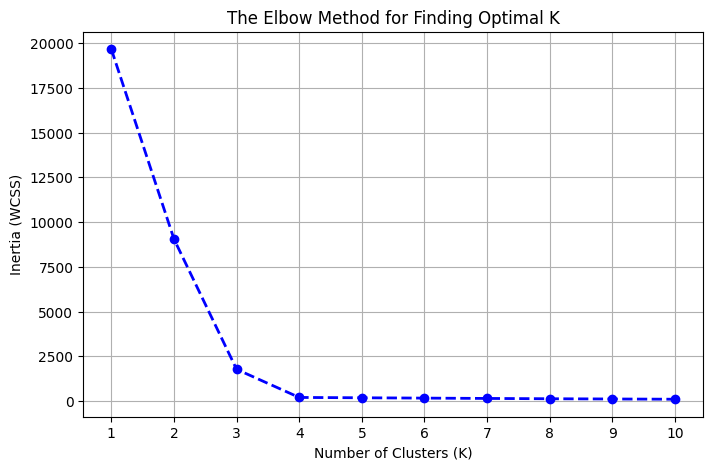

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 1. Generate a synthetic 2D dataset with 4 distinct clusters
X, _ = make_blobs(n_samples=300, centers=4, n_features=2, random_state=42, cluster_std=0.6)

# 2. Calculate Inertia for a range of K values (from 1 to 10)
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)
    print(f"K = {k} | Inertia = {kmeans.inertia_:.2f}")

# 3. Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o', color='b', linestyle='--', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('The Elbow Method for Finding Optimal K')
plt.xticks(k_range)
plt.grid(True)
plt.show()


## Hierarchical Clustering & DBSCAN

While K-Means is a centroid-based clustering algorithm, there are other powerful clustering paradigms in Machine Learning.

### 1. Hierarchical Clustering (Agglomerative)
* **What it is:** A bottom-up approach where each data point starts as its own cluster, and pairs of clusters are merged sequentially based on proximity until a single cluster remains.
* **Dendrogram:** A tree-like diagram that records the sequence of merges. By drawing a horizontal line across the dendrogram at a specific threshold, we can determine the optimal number of clusters.
* **Linkage Criteria:** Determines how the distance between two clusters is calculated:
  * **Ward:** Minimizes the variance of the clusters being merged (default and most common).
  * **Single:** Minimizes the distance between the closest points of the two clusters.
  * **Complete:** Minimizes the maximum distance between points of the two clusters.

### 2. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
* **What it is:** An algorithm that groups points based on spatial density. Unlike K-Means, it does not require specifying the number of clusters beforehand and is highly robust against outliers (noise).
* **Key Concepts:**
  * **Core Point:** A point with at least `min_samples` in its neighborhood of radius `eps`.
  * **Border Point:** A point that is within `eps` of a core point but has fewer than `min_samples` within its own neighborhood.
  * **Noise Point (Outlier):** Any point that is neither a core point nor a border point.
* **Key Parameters:**
  * **`eps` (epsilon):** The maximum distance between two samples to be considered in the same neighborhood.
  * **`min_samples`:** The minimum number of samples in a neighborhood for a point to be a core point.

---

### Python Code Example


Agglomerative Cluster Labels for the 15 samples: [1 1 2 0 2 0 2 1 0 1 2 0 2 0 1]


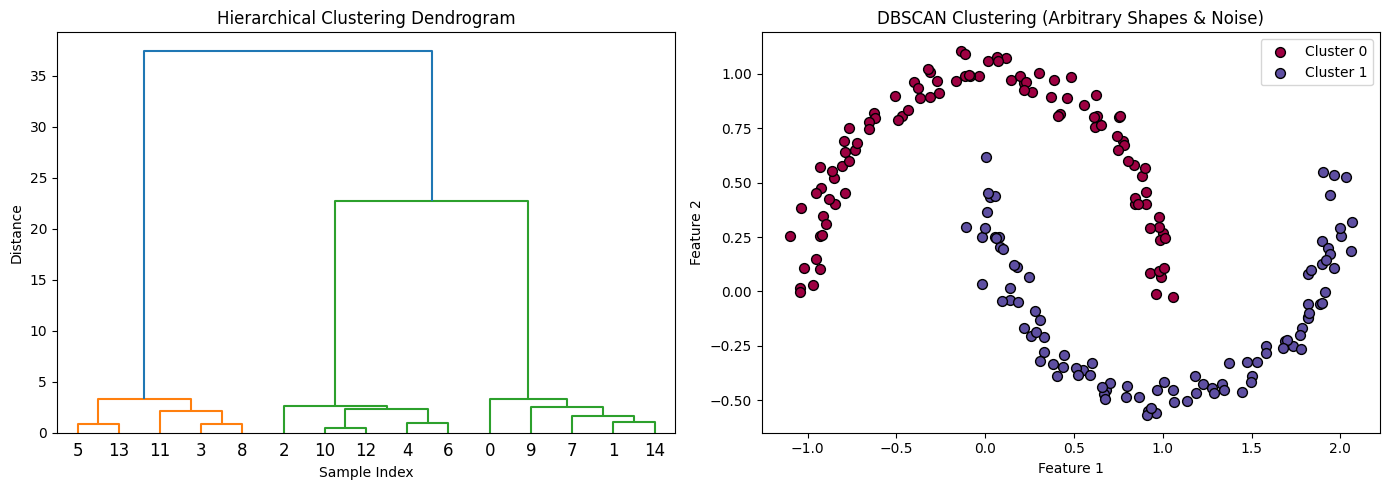

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons, make_blobs
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

# ----------------------------------------------------
# 1. Hierarchical Clustering (Dendrogram & Training)
# ----------------------------------------------------
# Generate a small blob dataset for clear dendrogram visualization
X_blobs, _ = make_blobs(n_samples=15, centers=3, random_state=42, cluster_std=1.0)

# Compute Linkage Matrix (using Ward's method)
Z = linkage(X_blobs, method='ward')

# Plot Dendrogram and DBSCAN side-by-side
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")

# Fit Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
agg_labels = agg.fit_predict(X_blobs)
print("Agglomerative Cluster Labels for the 15 samples:", agg_labels)

# ----------------------------------------------------
# 2. DBSCAN (Density-Based Clustering)
# ----------------------------------------------------
# Generate half-moon dataset (challenging for K-Means, ideal for DBSCAN)
X_moons, _ = make_moons(n_samples=200, noise=0.05, random_state=42)

# Train DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
db_labels = dbscan.fit_predict(X_moons)

# Plot DBSCAN Results
plt.subplot(1, 2, 2)
unique_labels = set(db_labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise points
        col = [0, 0, 0, 1]
    
    class_member_mask = (db_labels == k)
    xy = X_moons[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], color=tuple(col), edgecolor='k', s=50, label='Noise' if k == -1 else f'Cluster {k}')

plt.title("DBSCAN Clustering (Arbitrary Shapes & Noise)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.tight_layout()
plt.show()
